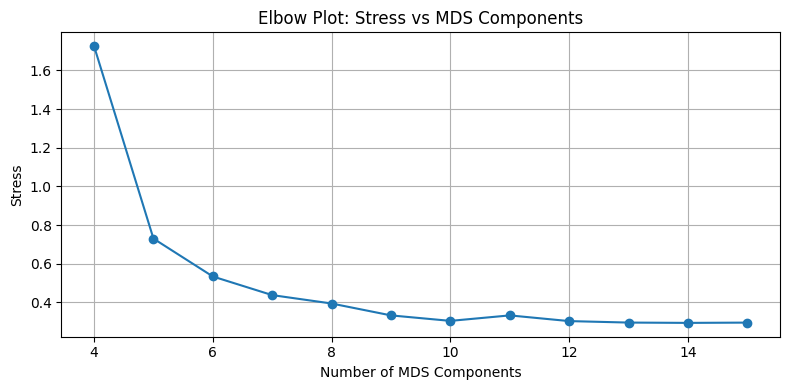

In [1]:
import pandas as pd
import glob
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Path to your single Parquet file
parquet_file = 'onion_dataset.parquet'
df_full = pd.read_parquet(parquet_file)  # requires 'zone' and 'timestamp'

# 2) Preprocess per zone
zone_dfs = {}
for zone, zone_df in df_full.groupby("zone"):
    zone_df = (zone_df.sort_values("timestamp")
                        .drop(columns=["zone"])
                        .set_index("timestamp"))
    zone_df = zone_df[~zone_df.index.duplicated(keep='first')].ffill().bfill().fillna(0)
    zone_dfs[zone] = zone_df

# 3) Find common timestamps across all zones
common_idx = None
for df in zone_dfs.values():
    common_idx = df.index if common_idx is None else common_idx.intersection(df.index)

# 4) Flatten aligned vectors
zones, vectors = [], []
for zone, df in zone_dfs.items():
    aligned = df.reindex(common_idx).ffill().bfill().fillna(0)
    zones.append(zone)
    vectors.append(aligned.values.flatten())
X = np.vstack(vectors)  # shape: (n_zones, n_hours * n_features)

# 5) Standardize
X_scaled = StandardScaler().fit_transform(X)

# 6) Correlation-based distance matrix
dist_corr = pairwise_distances(X_scaled, metric='correlation')

# 7) MDS stress curve
comp_range = range(4, 16)
stress_vals = []
for n_comp in comp_range:
    mds = MDS(n_components=n_comp,
              dissimilarity='precomputed',
              random_state=0,
              n_init=1,
              max_iter=300)
    mds.fit(dist_corr)
    stress_vals.append(mds.stress_)

# 8) Elbow plot
plt.figure(figsize=(8, 4))
plt.plot(list(comp_range), stress_vals, marker='o')
plt.xlabel('Number of MDS Components')
plt.ylabel('Stress')
plt.title('Elbow Plot: Stress vs MDS Components')
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# 9) Final embedding (e.g., 6D)
mds_final = MDS(n_components=7,
                dissimilarity='precomputed',
                random_state=0,
                n_init=1,
                max_iter=1000)
Y_final = mds_final.fit_transform(dist_corr)

# 10) DataFrame of zone embeddings
emb_cols = [f"Dim{i}" for i in range(1, 8)]
emb_df = pd.DataFrame(Y_final, index=zones, columns=emb_cols)
emb_df.to_csv("mds_embeddings.csv", index=True, float_format="%.6f")

print("MDS Embedding Vectors:")
print(emb_df)

MDS Embedding Vectors:
              Dim1      Dim2      Dim3      Dim4      Dim5      Dim6      Dim7
CH        0.308099  0.482874 -0.153829  0.041612 -0.505086 -0.001544  0.147934
CZ        0.078592  0.314296 -0.360940 -0.134434 -0.475105  0.010286  0.336721
DE-LU    -0.072257 -0.262525 -0.226460  0.651375 -0.110184  0.308238  0.084125
DK1      -0.331145  0.070053 -0.333501 -0.469594  0.027178 -0.173119  0.059992
DK2      -0.345404  0.208983 -0.311397 -0.459755 -0.026842 -0.141790 -0.017987
ES        0.140281  0.408309  0.115483  0.601030  0.357504  0.090782  0.026808
FI        0.012688 -0.632828  0.287978  0.064904 -0.077349 -0.096941  0.122587
FR       -0.081140  0.137914 -0.114178  0.747080 -0.317448  0.007246  0.060441
IT-North  0.100836  0.531304 -0.070247 -0.019773 -0.380037 -0.244330  0.358019
NL       -0.440096  0.203193 -0.416037 -0.001531 -0.356979  0.084262  0.018825
NO1       0.434461 -0.048340  0.109796 -0.200441  0.037353 -0.186999 -0.380564
NO2       0.181402 -0.016612 